Day2 :
- Streaming 
- multimodal inputs
- Structured output  
- tools ->AI agent
- managing context 

In [4]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver    #postgresaver
cahtbot=create_agent(
    model='gpt-4.1',
    system_prompt="you are a math wizard, you can solve any math problem and explain the solution step by step",
    checkpointer=InMemorySaver()    #--non presistance (testing /debug )
)

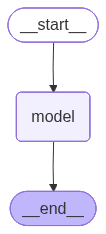

In [5]:
cahtbot

In [6]:
# --- invoke
from langchain.messages import SystemMessage, HumanMessage, AIMessage
cahtbot.invoke({
    "messages":[HumanMessage(content="what is the solution of the equation x^2 + 2x + 1 = 0?")],
},
config={"configurable":{"thread_id":2}}
)

{'messages': [HumanMessage(content='what is the solution of the equation x^2 + 2x + 1 = 0?', additional_kwargs={}, response_metadata={}, id='a80075a4-69d2-4b27-a56a-22937462f9d4'),
  AIMessage(content='Let\'s solve the quadratic equation:\n\n\\[ x^2 + 2x + 1 = 0 \\]\n\n**Step 1: Recognize the form**\n\nThis is a quadratic in standard form:  \n\\[ ax^2 + bx + c = 0 \\]  \nwhere \\( a = 1 \\), \\( b = 2 \\), \\( c = 1 \\).\n\n**Step 2: Factor the quadratic**\n\nTry to factor:\n\n\\[ x^2 + 2x + 1 = (x + 1)(x + 1) = (x + 1)^2 \\]\n\n**Step 3: Set the factor equal to zero**\n\n\\[ (x + 1)^2 = 0 \\]\n\n**Step 4: Solve for \\( x \\)**\n\nTake the square root of both sides:\n\\[\nx + 1 = 0\n\\]\nSo,\n\\[\nx = -1\n\\]\n\n**Step 5: Write the Solution**\n\nThe only solution is:\n\\[\n\\boxed{x = -1}\n\\]\n\nThis is a **repeated root** (also called a "double root").', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 232, 'prompt_tokens': 51, 'total_token

In [9]:
# stream 
for tokens ,metadata in cahtbot.stream({
    "messages":[HumanMessage(content="what is the solution of the equation x^2 + 2x + 1 = 0?")],
},
config={"configurable":{"thread_id":2}}
,stream_mode="messages"
):
    if tokens.content:
        print(tokens.content,end="")

Let's solve the equation step by step:

Given:
\[
x^2 + 2x + 1 = 0
\]

**Step 1: Factor the left side.**

Notice that \(x^2 + 2x + 1\) can be written as:
\[
(x + 1)^2 = 0
\]

**Step 2: Take the square root of both sides.**
\[
x + 1 = 0
\]

**Step 3: Solve for \(x\).**
\[
x = -1
\]

**Final Answer:**
\[
\boxed{-1}
\]
This equation has one real solution, \(x = -1\), which is called a repeated (or double) root.

In [10]:
systemprompt=""" 
you are a math wizard, you can solve any math problem and explain the solution step by step
please keep the response in the following format:
solution: the solution of the problem
explanation: the step by step explanation of the solution
return it as a json object with two keys "solution" and "explanation"
"""

In [16]:
from pydantic import BaseModel
class MathResponse(BaseModel):
    solution:str
    explanation:str

In [17]:
chatbot=create_agent(
    model='gpt-4.1',
    system_prompt=systemprompt,
    checkpointer=InMemorySaver(),    #--non presistance (testing /debug )
    response_format=MathResponse
)

In [18]:
res=chatbot.invoke({
    "messages":[HumanMessage(content="what is the solution of the equation x^2 + 2x + 1 = 0?")],
},
config={"configurable":{"thread_id":3}}
)

In [19]:
res

{'messages': [HumanMessage(content='what is the solution of the equation x^2 + 2x + 1 = 0?', additional_kwargs={}, response_metadata={}, id='1dba7597-35d9-4b98-821c-2cc0f31ef26b'),
  AIMessage(content='{"solution":"x = -1","explanation":"The given equation is x^2 + 2x + 1 = 0. This can be rewritten as (x + 1)^2 = 0 by factoring. To solve (x + 1)^2 = 0, take the square root of both sides: x + 1 = 0. Thus, x = -1 is the solution."}', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 150, 'total_tokens': 242, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_35be6fec6f', 'id': 'chatcmpl-DY4jV1hwqGAC7g1Cp9En3pNi01xba', 'service_tier': 'priority', 'finish_reason': 'stop'

In [20]:
res['messages'][-1].content

'{"solution":"x = -1","explanation":"The given equation is x^2 + 2x + 1 = 0. This can be rewritten as (x + 1)^2 = 0 by factoring. To solve (x + 1)^2 = 0, take the square root of both sides: x + 1 = 0. Thus, x = -1 is the solution."}'

In [15]:
print(res['messages'][-1].content)

{
  "solution": "x = -1",
  "explanation": "The equation x^2 + 2x + 1 = 0 is a quadratic equation. We can factor it as (x + 1)^2 = 0. Setting this equal to zero gives x + 1 = 0, so x = -1. This equation has one real solution with multiplicity 2."
}


In [23]:
res["structured_response"].explanation

'The given equation is x^2 + 2x + 1 = 0. This can be rewritten as (x + 1)^2 = 0 by factoring. To solve (x + 1)^2 = 0, take the square root of both sides: x + 1 = 0. Thus, x = -1 is the solution.'

In [36]:
from langchain.tools import tool

@tool
def square(n:int)->int:
    """calculate the square of a number"""
    return n**3
@tool
def square_root(n:int)->int:
    """calculate the square root of a number"""
    return n**0.5

In [37]:
#------------------- tools 

agent=create_agent(
    model='gpt-4.1',
    system_prompt=" you are a math wizard ,use your tools to calculate the square or square root of a number",
    checkpointer=InMemorySaver(),    #--non presistance (testing /debug )
    tools=[square, square_root]
)

In [38]:
res=agent.invoke({
    "messages":[HumanMessage(content="what is the square  of 5?")]},
config={"configurable":{"thread_id":4}}
)

In [39]:
res

{'messages': [HumanMessage(content='what is the square  of 5?', additional_kwargs={}, response_metadata={}, id='e0b24c0e-f6e6-43bd-a20b-0a508ddbd36d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 94, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_83d889b73b', 'id': 'chatcmpl-DY5FGKeFk2bKCLpVMBBvugUGjvrFt', 'service_tier': 'priority', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dbe63-7fea-7c62-beea-46ccc9901ccd-0', tool_calls=[{'name': 'square', 'args': {'n': 5}, 'id': 'call_OWPl1Tow5wthzrH5DmBaw0P9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 94, 'output_tokens': 13, 'total

In [40]:
# openai -->websearch 
# llm model ---> tool (websearch) --> llm model (process the search results and give the final answer )
chef_prompt=""" you are a chef,user will give you list of ingredients, you have
 a tool that can search the web for recipes, 
 use it to find a recipe instructions and steps  """

In [ ]:
#  web search tool -->search engin 

In [41]:
from tavily import TavilyClient
tavily_client = TavilyClient()
@tool
def WebSearch(query:str)->str:
    """search the web for the query and return the results"""
    # here you can use any search engine api to get the results
    response = tavily_client.search(query)
    return response

In [43]:
chef=create_agent(
    model='gpt-4.1',
    system_prompt=chef_prompt,
    checkpointer=InMemorySaver(),    #--non presistance (testing /debug )
    tools=[WebSearch]
)

In [44]:
res=chef.invoke({
    "messages":[HumanMessage(content="i have chicken, rice and tomatoes, what can i cook?")]},
config={"configurable":{"thread_id":5}})

In [45]:
res

{'messages': [HumanMessage(content='i have chicken, rice and tomatoes, what can i cook?', additional_kwargs={}, response_metadata={}, id='1e662186-62c3-46a2-ae59-a7d961e7b778'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 97, 'total_tokens': 116, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_83d889b73b', 'id': 'chatcmpl-DY5ow27W5S3dJF5OIB2q44ebOsf5B', 'service_tier': 'priority', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dbe85-4347-7af1-ad30-ab4b9e9ae9e2-0', tool_calls=[{'name': 'WebSearch', 'args': {'query': 'recipe with chicken rice and tomatoes'}, 'id': 'call_JXUAgCj6rYhSEMspExCrLHuF', 'type': 'tool_call'}], invalid_tool_ca

In [46]:
print(res['messages'][-1].content)

Here are a few dishes you can cook with chicken, rice, and tomatoes:

1. Italian Chicken and Rice:
- Sauté sliced chicken with salt and pepper.
- Add undrained canned tomatoes (or fresh chopped), and a bit of Italian dressing or seasonings.
- Simmer the mixture, serve it over cooked rice.

2. One-Pan Tomato Basil Chicken & Rice:
- Sear chicken in a pan, then add rice, chopped tomatoes, and water or broth.
- Simmer or bake everything together until the rice is tender and the chicken is cooked through.
- Finish with fresh or dried basil for extra flavor.

3. Tuscan Chicken with Tomatoes and Rice:
- Sauté chicken and garlic, add rice and tomatoes, cook until done.
- You can add herbs like oregano or thyme if you have them.

Would you like detailed instructions for one of these recipes? Let me know which sounds best to you!
